In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Show first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [3]:
# Statistical Summary
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [4]:
# Check Missing Values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
# Remove missing values
df = df.dropna()

df.columns = df.columns.str.strip()

# Check new shape
print(df.shape)

(740, 7)


In [6]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [7]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [8]:
print(type(df))
print(df.shape)
print(df.columns.tolist())

<class 'pandas.DataFrame'>
(740, 7)
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [9]:
import pandas as pd
import seaborn as sns

print(pd.__version__)
print(sns.__version__)

3.0.3
0.13.2


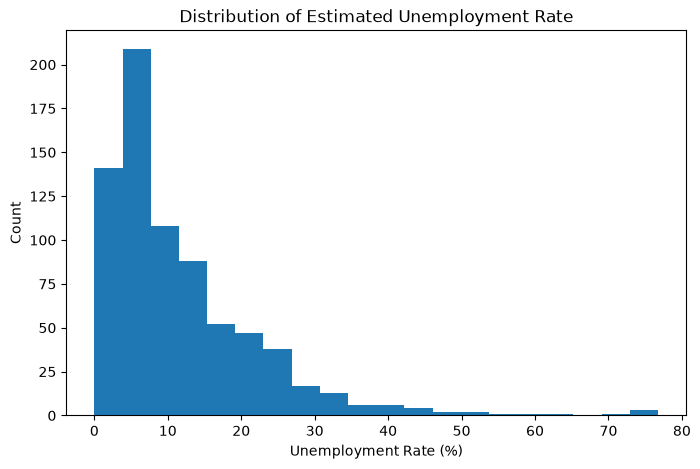

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Estimated Unemployment Rate (%)"], bins=20)

plt.title("Distribution of Estimated Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.show()

In [11]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [12]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


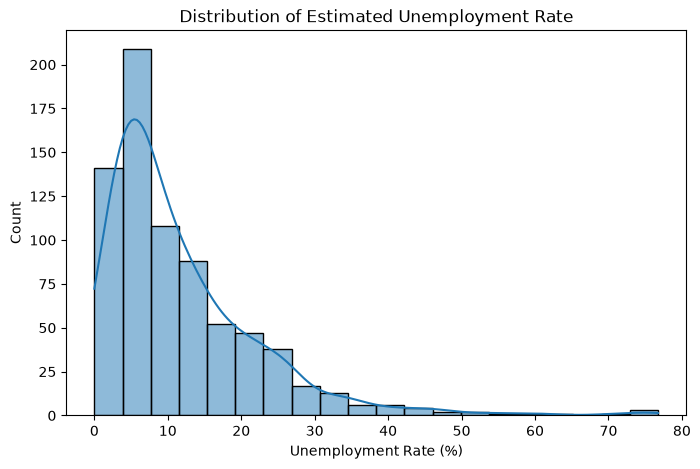

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Estimated Unemployment Rate (%)",
    bins=20,
    kde=True
)

plt.title("Distribution of Estimated Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.show()

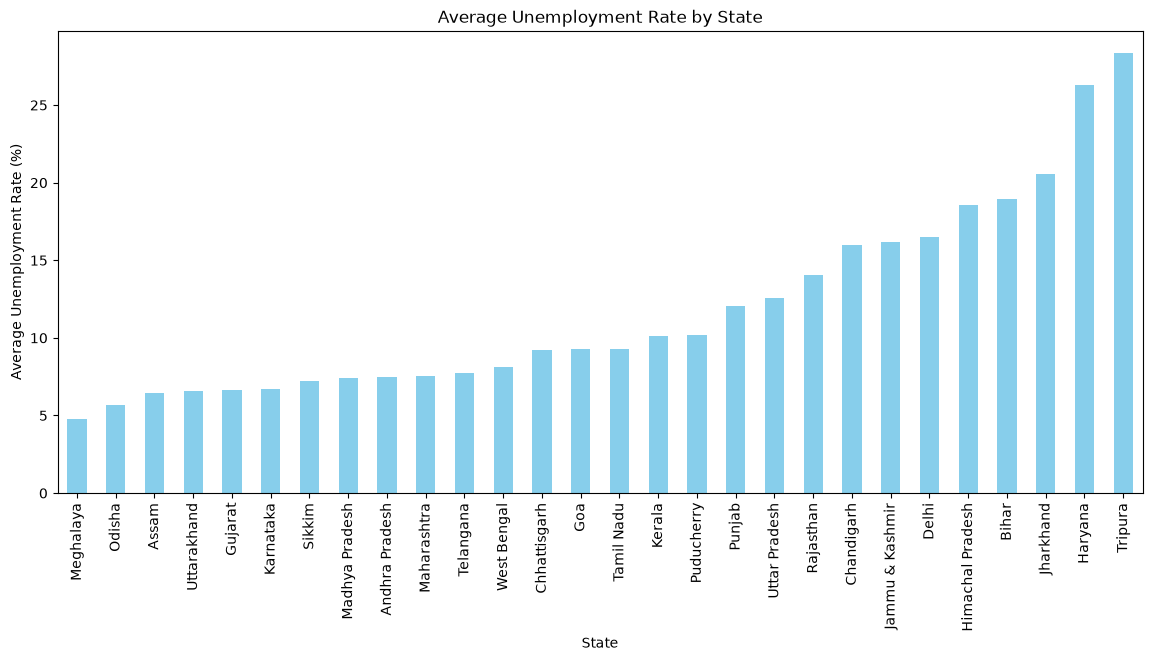

In [14]:
plt.figure(figsize=(14,6))

state_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

state_avg.plot(kind="bar", color="skyblue")

plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

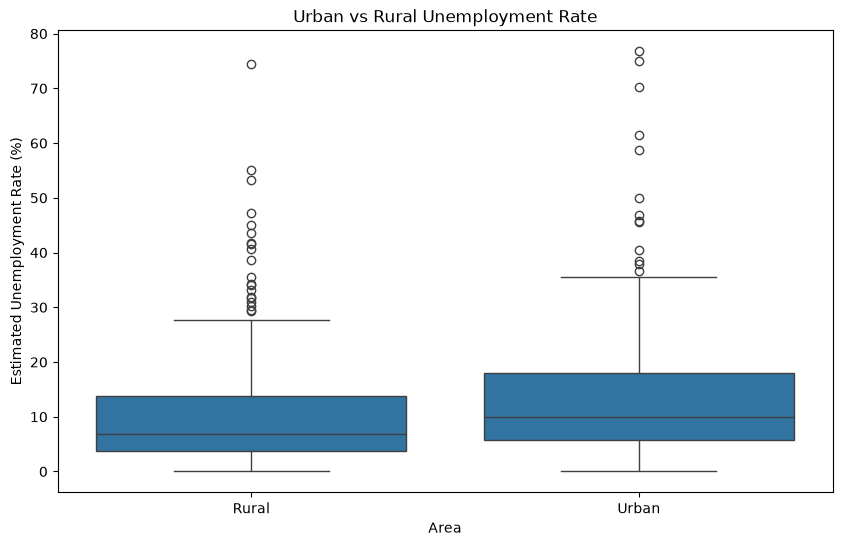

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Urban vs Rural Unemployment Rate")

plt.show()

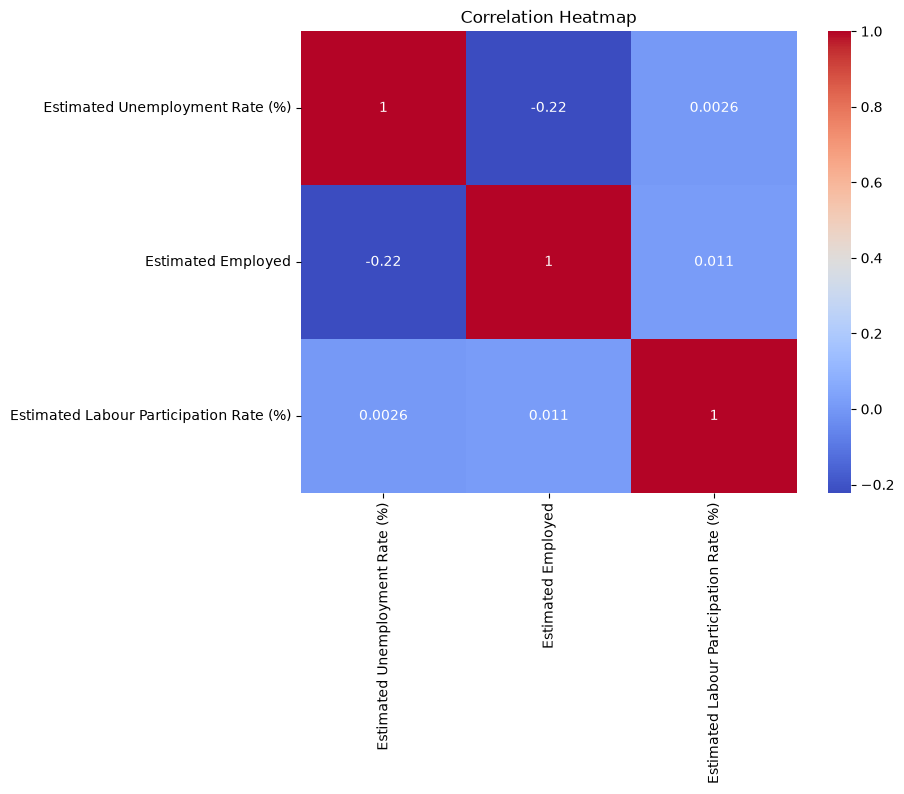

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

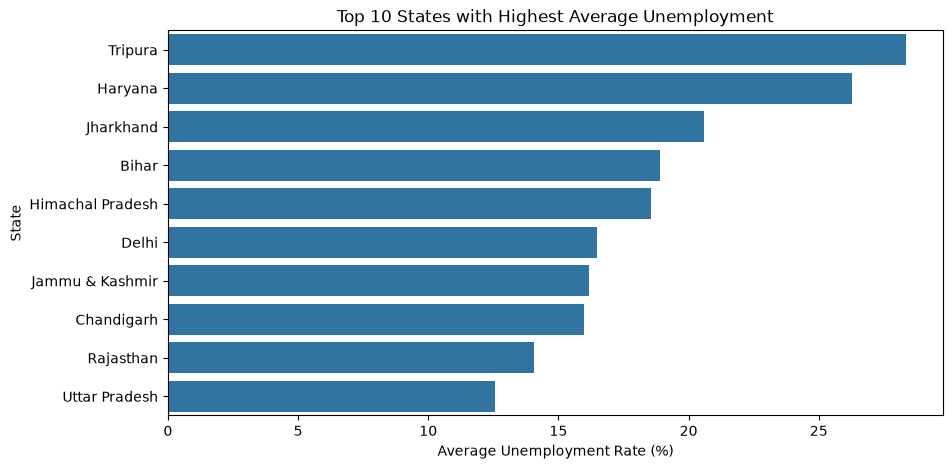

In [17]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

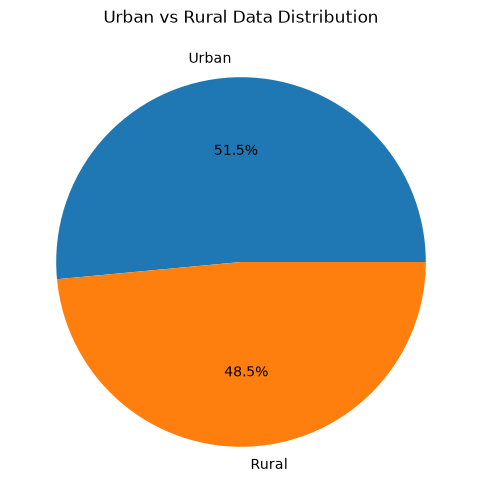

In [18]:
plt.figure(figsize=(6,6))

df["Area"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Urban vs Rural Data Distribution")

plt.show()

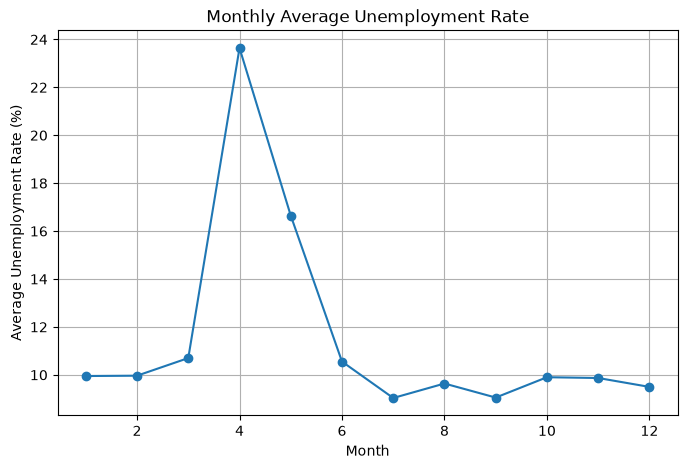

In [19]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

monthly = df.groupby(df["Date"].dt.month)["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(8,5))

monthly.plot(marker="o")

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

In [20]:
print(type(df))
print(df.head())

<class 'pandas.DataFrame'>
           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
